# Long Short-Term Memory (LSTM): Learning Long-Term Dependencies in Sequential Data

This is the fifth notebook in the **AI NLP LLM Notes** learning path.

The previous notebook introduced Recurrent Neural Networks and showed how hidden states allow neural networks to process text as a sequence. This notebook continues from that foundation and explains why **Long Short-Term Memory (LSTM)** networks became necessary.

# Introduction

Word embeddings convert words into dense numerical vectors. RNNs process those vectors one token at a time and update a hidden state as the sequence unfolds.

The challenge is memory. Vanilla RNNs can struggle to preserve information from early tokens when a sentence is long. LSTM networks were introduced to address this limitation with a more controlled memory system based on **cell states** and **gates**.

In this notebook, we will build intuition for LSTM architecture and train a practical sentiment classification model using TensorFlow/Keras.

**Dependency note:** this notebook uses TensorFlow. If it is not installed, run `pip install tensorflow` in your environment.

## Why Vanilla RNNs Fail

Vanilla RNNs update their hidden state at every time step. This makes them suitable for short sequences, but fragile when important information appears far away from the final prediction.

Consider:

`The movie that I watched three weeks ago was surprisingly amazing.`

To classify the sentiment correctly, the model should remember that the sentence is about a `movie` while processing many later words. In long sentences, vanilla RNNs often behave like they have short-term memory: recent tokens dominate, and earlier context fades.

The two core training problems are:

- **vanishing gradients**: learning signals become too small across many time steps,
- **exploding gradients**: learning signals become too large and destabilize training.

In [1]:
import random
import re
import string

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

try:
    import tensorflow as tf
    from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.utils import to_categorical
except ImportError as error:
    raise ImportError(
        "This notebook requires TensorFlow. Install it with: pip install tensorflow"
    ) from error

In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "axes.facecolor": "#FAFAFA",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#222222",
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "font.family": "DejaVu Sans",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,
        "xtick.color": "#222222",
        "ytick.color": "#222222",
    }
)

PRIMARY_COLOR = "#2F6F9F"
SECONDARY_COLOR = "#D95F59"
ACCENT_COLOR = "#3A9D7C"
WARNING_COLOR = "#E0A23B"
NEUTRAL_COLOR = "#6B7280"

## The Vanishing Gradient Problem

During training, neural networks update weights using gradients. In recurrent networks, gradients must flow backward through many time steps.

If each step slightly shrinks the gradient, repeated multiplication can make the signal almost disappear:

\[
0.8^{20} \approx 0.01
\]

No advanced calculus is needed for the intuition: if the learning signal becomes tiny before it reaches early tokens, the model struggles to learn that early words matter.

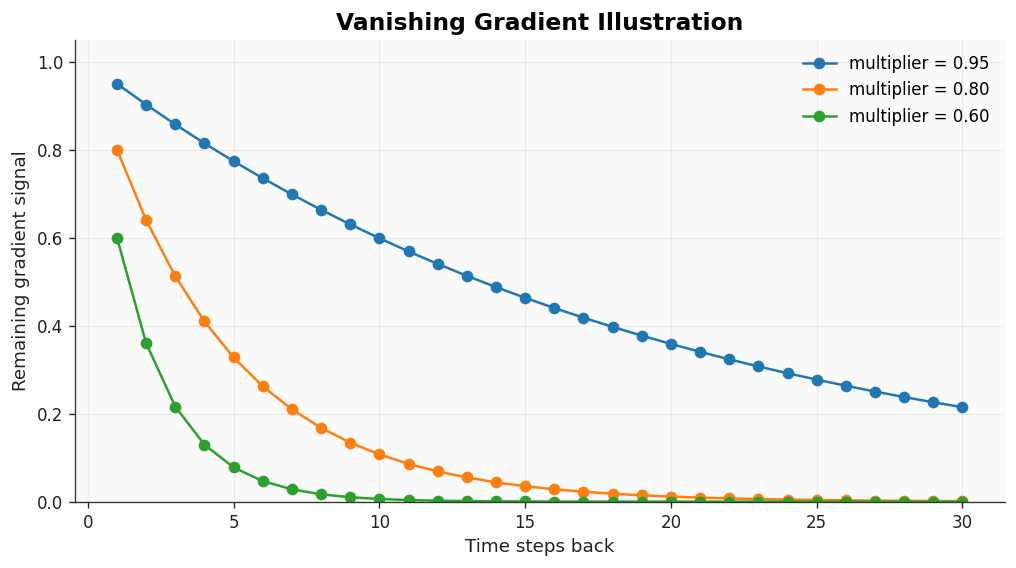

In [3]:
def plot_vanishing_gradient():
    """Visualize how repeated multiplication can shrink gradients."""
    time_steps = np.arange(1, 31)
    gradient_95 = 0.95 ** time_steps
    gradient_80 = 0.80 ** time_steps
    gradient_60 = 0.60 ** time_steps

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(time_steps, gradient_95, marker="o", label="multiplier = 0.95")
    ax.plot(time_steps, gradient_80, marker="o", label="multiplier = 0.80")
    ax.plot(time_steps, gradient_60, marker="o", label="multiplier = 0.60")
    ax.set_title("Vanishing Gradient Illustration")
    ax.set_xlabel("Time steps back")
    ax.set_ylabel("Remaining gradient signal")
    ax.set_ylim(0, 1.05)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.45)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.show()


plot_vanishing_gradient()

## What is LSTM?

An LSTM is a recurrent neural network architecture designed to preserve useful information for longer periods.

It introduces:

- **Memory Cell**: a controlled path for storing information,
- **Cell State**: the long-term memory stream,
- **Hidden State**: the output representation passed to the next step and downstream layers.

Instead of repeatedly overwriting one hidden state, LSTM uses gates to decide what to forget, what to add, and what to output.

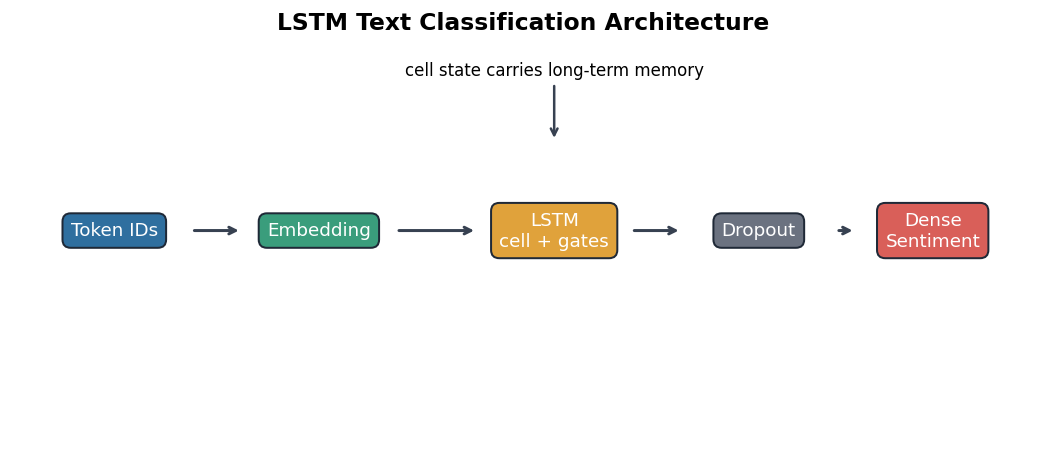

In [4]:
def draw_lstm_architecture():
    """Draw a high-level LSTM architecture diagram."""
    fig, ax = plt.subplots(figsize=(11, 4.2))
    ax.axis("off")

    boxes = [
        ("Token IDs", 0.10, PRIMARY_COLOR),
        ("Embedding", 0.30, ACCENT_COLOR),
        ("LSTM\ncell + gates", 0.53, WARNING_COLOR),
        ("Dropout", 0.73, NEUTRAL_COLOR),
        ("Dense\nSentiment", 0.90, SECONDARY_COLOR),
    ]

    for label, x_position, color in boxes:
        ax.text(
            x_position,
            0.55,
            label,
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            bbox={
                "boxstyle": "round,pad=0.45",
                "facecolor": color,
                "edgecolor": "#1F2937",
                "linewidth": 1.2,
            },
        )

    for (_, start, _), (_, end, _) in zip(boxes[:-1], boxes[1:]):
        ax.annotate(
            "",
            xy=(end - 0.075, 0.55),
            xytext=(start + 0.075, 0.55),
            arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#374151"},
        )

    ax.annotate(
        "cell state carries long-term memory",
        xy=(0.53, 0.78),
        xytext=(0.53, 0.95),
        ha="center",
        fontsize=10,
        arrowprops={"arrowstyle": "->", "lw": 1.5, "color": "#374151"},
    )
    ax.set_title("LSTM Text Classification Architecture", pad=16)
    plt.show()


draw_lstm_architecture()

## Understanding the Gates

LSTM gates are small neural network components that control information flow.

Each gate uses a sigmoid-like decision value between 0 and 1:

- values near 0 mean "block most of this information",
- values near 1 mean "let most of this information pass".

This gives LSTM a more stable memory mechanism than a vanilla RNN.

**Forget Gate:** decides which old information should be removed from the cell state. A real-world analogy is clearing outdated context before solving the next part of a problem.

**Input Gate:** decides which new information should be written into memory. A real-world analogy is deciding which new notes are important enough to add to a project summary.

**Output Gate:** decides which memory should be exposed as the hidden state. A real-world analogy is giving a concise answer while keeping more background context internally.

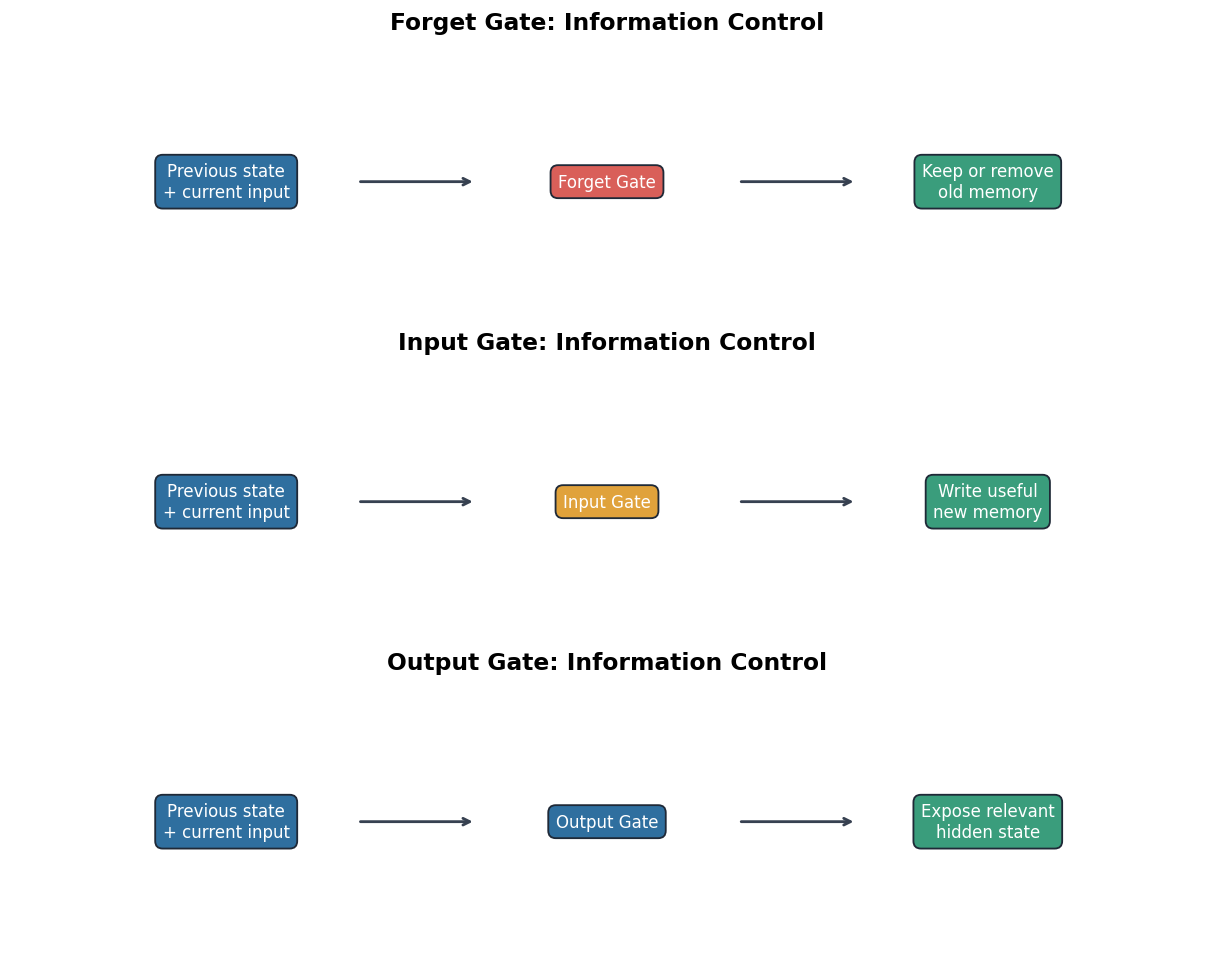

In [5]:
def draw_gate_diagrams():
    """Draw forget, input, and output gate diagrams."""
    gate_specs = [
        ("Forget Gate", "Keep or remove\nold memory", SECONDARY_COLOR),
        ("Input Gate", "Write useful\nnew memory", WARNING_COLOR),
        ("Output Gate", "Expose relevant\nhidden state", PRIMARY_COLOR),
    ]

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), constrained_layout=True)

    for axis, (gate_name, purpose, color) in zip(axes, gate_specs):
        axis.axis("off")
        nodes = [
            ("Previous state\n+ current input", 0.18, PRIMARY_COLOR),
            (gate_name, 0.50, color),
            (purpose, 0.82, ACCENT_COLOR),
        ]

        for label, x_position, node_color in nodes:
            axis.text(
                x_position,
                0.50,
                label,
                ha="center",
                va="center",
                color="white",
                fontsize=10,
                bbox={
                    "boxstyle": "round,pad=0.45",
                    "facecolor": node_color,
                    "edgecolor": "#1F2937",
                    "linewidth": 1.1,
                },
            )

        for (_, start, _), (_, end, _) in zip(nodes[:-1], nodes[1:]):
            axis.annotate(
                "",
                xy=(end - 0.11, 0.50),
                xytext=(start + 0.11, 0.50),
                arrowprops={"arrowstyle": "->", "lw": 1.7, "color": "#374151"},
            )
        axis.set_title(f"{gate_name}: Information Control", pad=8)

    plt.show()


draw_gate_diagrams()

## Memory Cell Flow

The cell state is the key idea behind LSTM. It creates a path where information can move through time with fewer destructive updates.

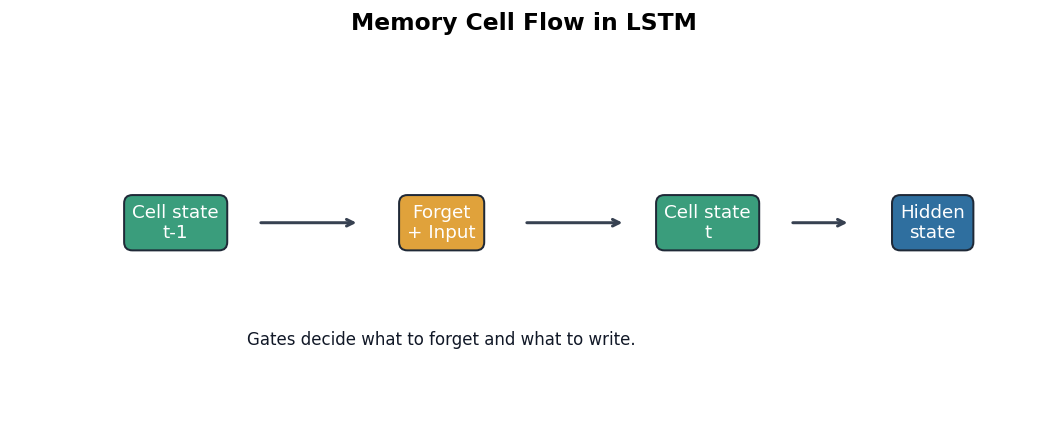

In [6]:
def draw_memory_cell_flow():
    """Draw how the LSTM cell state preserves information through time."""
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.axis("off")

    x_positions = [0.16, 0.42, 0.68, 0.90]
    labels = ["Cell state\nt-1", "Forget\n+ Input", "Cell state\nt", "Hidden\nstate"]
    colors = [ACCENT_COLOR, WARNING_COLOR, ACCENT_COLOR, PRIMARY_COLOR]

    for label, x_position, color in zip(labels, x_positions, colors):
        ax.text(
            x_position,
            0.55,
            label,
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            bbox={
                "boxstyle": "round,pad=0.45",
                "facecolor": color,
                "edgecolor": "#1F2937",
                "linewidth": 1.2,
            },
        )

    for start, end in zip(x_positions[:-1], x_positions[1:]):
        ax.annotate(
            "",
            xy=(end - 0.08, 0.55),
            xytext=(start + 0.08, 0.55),
            arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#374151"},
        )

    ax.text(
        0.42,
        0.22,
        "Gates decide what to forget and what to write.",
        ha="center",
        fontsize=10,
        color="#111827",
    )
    ax.set_title("Memory Cell Flow in LSTM", pad=16)
    plt.show()


draw_memory_cell_flow()

## RNN vs LSTM

LSTM is still recurrent, but it has a more structured memory system. The tradeoff is that LSTM is more powerful but also heavier than a vanilla RNN.

In [7]:
rnn_lstm_comparison = pd.DataFrame(
    {
        "Aspect": [
            "Memory",
            "Training Stability",
            "Long-Term Dependencies",
            "Gradient Flow",
            "Performance",
            "Applications",
        ],
        "Vanilla RNN": [
            "Single hidden state updated at every step",
            "Often unstable on long sequences",
            "Weak for distant context",
            "Prone to vanishing or exploding gradients",
            "Good baseline for short sequences",
            "Simple sequence classification and small demos",
        ],
        "LSTM": [
            "Hidden state plus cell state",
            "More stable due to gating",
            "Better at preserving distant information",
            "Gates help protect useful gradient paths",
            "Stronger for many classic sequence tasks",
            "Translation, speech, forecasting, text generation",
        ],
    }
)

display(rnn_lstm_comparison)

,Aspect,Vanilla RNN,LSTM
0,Memory,Single hidden state updated at every step,Hidden state plus cell state
1,Training Stability,Often unstable on long sequences,More stable due to gating
2,Long-Term Dependencies,Weak for distant context,Better at preserving distant information
3,Gradient Flow,Prone to vanishing or exploding gradients,Gates help protect useful gradient paths
4,Performance,Good baseline for short sequences,Stronger for many classic sequence tasks
5,Applications,Simple sequence classification and small demos,"Translation, speech, forecasting, text generation"


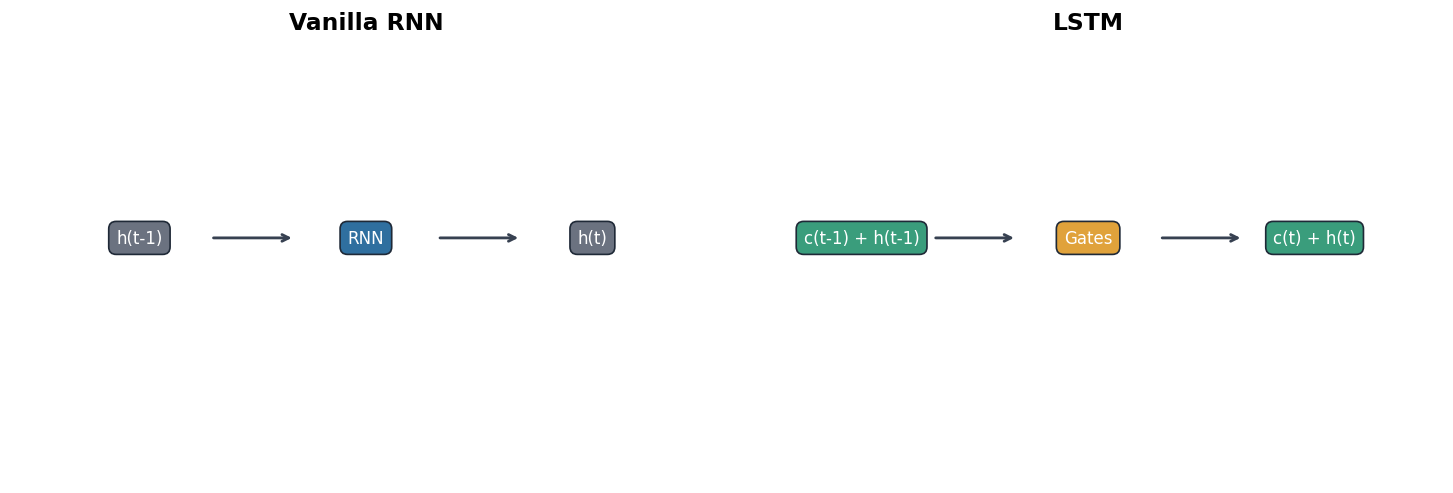

In [8]:
def draw_rnn_vs_lstm_diagram():
    """Draw a conceptual comparison between RNN and LSTM memory."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    for axis, title, labels, colors in [
        (
            axes[0],
            "Vanilla RNN",
            ["h(t-1)", "RNN", "h(t)"],
            [NEUTRAL_COLOR, PRIMARY_COLOR, NEUTRAL_COLOR],
        ),
        (
            axes[1],
            "LSTM",
            ["c(t-1) + h(t-1)", "Gates", "c(t) + h(t)"],
            [ACCENT_COLOR, WARNING_COLOR, ACCENT_COLOR],
        ),
    ]:
        axis.axis("off")
        x_positions = [0.18, 0.50, 0.82]
        for label, x_position, color in zip(labels, x_positions, colors):
            axis.text(
                x_position,
                0.55,
                label,
                ha="center",
                va="center",
                color="white",
                fontsize=10,
                bbox={
                    "boxstyle": "round,pad=0.45",
                    "facecolor": color,
                    "edgecolor": "#1F2937",
                },
            )
        for start, end in zip(x_positions[:-1], x_positions[1:]):
            axis.annotate(
                "",
                xy=(end - 0.10, 0.55),
                xytext=(start + 0.10, 0.55),
                arrowprops={"arrowstyle": "->", "lw": 1.7, "color": "#374151"},
            )
        axis.set_title(title)

    plt.show()


draw_rnn_vs_lstm_diagram()

## Dataset

We will build a realistic sentiment analysis dataset with three classes:

- `positive`
- `negative`
- `neutral`

The dataset contains 120 short sentences across software products, customer support, healthcare, finance, education, and operations. It is small enough to train quickly but varied enough for a meaningful notebook demo.

In [9]:
positive_sentences = [
    "The support team solved my account issue quickly",
    "The dashboard is clean and easy to understand",
    "The payment process worked perfectly this morning",
    "The mobile app feels reliable after the update",
    "The product documentation answered my question",
    "The training session was useful and practical",
    "The hospital portal made appointment booking simple",
    "The finance report gave clear insights",
    "The security update installed without disruption",
    "The recommendation feature suggested relevant content",
    "The API response time improved noticeably",
    "The onboarding workflow felt smooth and professional",
    "The chatbot handled my request accurately",
    "The search results matched my intent",
    "The new release made daily work easier",
    "The customer agent explained the refund policy clearly",
    "The analytics tool saved the team hours",
    "The course examples were realistic and helpful",
    "The system recovered gracefully after maintenance",
    "The quality review found no major issues",
    "The user interface feels polished and intuitive",
    "The deployment finished ahead of schedule",
    "The email notification arrived instantly",
    "The model predictions improved after retraining",
    "The billing page loaded quickly",
    "The clinical summary was concise and accurate",
    "The finance dashboard highlighted the right risks",
    "The learning platform kept students engaged",
    "The password reset process was simple",
    "The monitoring alert helped prevent downtime",
    "The upgrade reduced manual work significantly",
    "The support article explained every step",
    "The team delivered excellent service",
    "The application stayed stable during peak traffic",
    "The report format was professional and clear",
    "The new search filter improved productivity",
    "The appointment reminder was timely and useful",
    "The transaction history was easy to export",
    "The product experience exceeded expectations",
    "The feedback form was simple to complete",
]

negative_sentences = [
    "The app crashed during checkout",
    "The dashboard is slow and confusing",
    "The payment failed without a useful message",
    "The mobile update introduced several bugs",
    "The documentation missed important setup details",
    "The training session was unclear and rushed",
    "The hospital portal rejected a valid appointment",
    "The finance report contained outdated numbers",
    "The security alert arrived too late",
    "The recommendation feature repeated irrelevant content",
    "The API timeout blocked the workflow",
    "The onboarding process took too long",
    "The chatbot misunderstood my billing issue",
    "The search results were unrelated to my query",
    "The new release made the system unstable",
    "The customer agent gave inconsistent answers",
    "The analytics tool produced incorrect charts",
    "The course examples were incomplete",
    "The system lost data during synchronization",
    "The quality review found serious regressions",
    "The user interface feels cluttered and frustrating",
    "The deployment failed at the final step",
    "The email notification never arrived",
    "The model predictions were unreliable",
    "The billing page froze repeatedly",
    "The clinical summary missed critical information",
    "The finance dashboard hid important risks",
    "The learning platform confused students",
    "The password reset link expired immediately",
    "The monitoring alert failed to detect downtime",
    "The upgrade created extra manual work",
    "The support article skipped key instructions",
    "The team delivered poor service",
    "The application slowed down during peak traffic",
    "The report format was messy and hard to read",
    "The search filter removed relevant results",
    "The appointment reminder arrived after the visit",
    "The transaction history export was broken",
    "The product experience was disappointing",
    "The feedback form failed to submit",
]

neutral_sentences = [
    "The support ticket was assigned to a specialist",
    "The dashboard displays weekly activity metrics",
    "The payment receipt includes a transaction ID",
    "The mobile app requires an internet connection",
    "The documentation contains an installation section",
    "The training session lasts ninety minutes",
    "The hospital portal stores appointment history",
    "The finance report covers the previous quarter",
    "The security policy requires multi factor authentication",
    "The recommendation feature uses browsing history",
    "The API returns data in JSON format",
    "The onboarding process includes identity verification",
    "The chatbot collects account details before routing",
    "The search index refreshes every night",
    "The new release is scheduled for Friday",
    "The customer agent opened a follow up case",
    "The analytics tool supports CSV exports",
    "The course includes five modules",
    "The system maintenance window starts at midnight",
    "The quality review checklist has ten items",
    "The user interface includes a settings panel",
    "The deployment pipeline has three approval stages",
    "The email notification contains a reference number",
    "The model training job started this morning",
    "The billing page shows account balance",
    "The clinical summary lists medication names",
    "The finance dashboard tracks monthly revenue",
    "The learning platform records student progress",
    "The password reset page asks for email confirmation",
    "The monitoring alert is visible in the dashboard",
    "The upgrade package is available for download",
    "The support article was updated yesterday",
    "The team will review the request tomorrow",
    "The application logs are stored for thirty days",
    "The report format follows the company template",
    "The search filter supports date ranges",
    "The appointment reminder includes location details",
    "The transaction history shows pending payments",
    "The product survey contains ten questions",
    "The feedback form asks for contact information",
]

dataset_rows = []
for label, sentences in [
    ("positive", positive_sentences),
    ("negative", negative_sentences),
    ("neutral", neutral_sentences),
]:
    dataset_rows.extend({"text": sentence, "label": label} for sentence in sentences)

dataset_df = pd.DataFrame(dataset_rows).sample(
    frac=1,
    random_state=RANDOM_SEED,
).reset_index(drop=True)

display(dataset_df.head(12))
print(f"Dataset size: {len(dataset_df)} sentences")
display(dataset_df["label"].value_counts().rename("count").to_frame())

,text,label
0,The documentation missed important setup details,negative
1,The finance report contained outdated numbers,negative
2,The product documentation answered my question,positive
3,The customer agent gave inconsistent answers,negative
4,The finance dashboard highlighted the right risks,positive
5,The billing page froze repeatedly,negative
6,The application slowed down during peak traffic,negative
7,The API response time improved noticeably,positive
8,The app crashed during checkout,negative
9,The learning platform records student progress,neutral


Dataset size: 120 sentences


,count
label,
negative,40
positive,40
neutral,40


## Text Preprocessing

The preprocessing workflow is:

1. lowercase text,
2. tokenize with Keras `Tokenizer`,
3. build a vocabulary,
4. encode sentences as integer sequences,
5. pad sequences to the same length.

Padding turns variable-length sentences into rectangular tensors that neural networks can train on efficiently.

In [10]:
def clean_text(text):
    """Lowercase text and remove punctuation."""
    lowercase_text = text.lower()
    return lowercase_text.translate(str.maketrans("", "", string.punctuation))


dataset_df["clean_text"] = dataset_df["text"].apply(clean_text)

train_texts, validation_texts, train_labels, validation_labels = train_test_split(
    dataset_df["clean_text"],
    dataset_df["label"],
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=dataset_df["label"],
)

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
validation_sequences = tokenizer.texts_to_sequences(validation_texts)

max_sequence_length = max(len(sequence) for sequence in train_sequences)
vocabulary_size = len(tokenizer.word_index) + 1

train_padded = pad_sequences(
    train_sequences,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post",
)
validation_padded = pad_sequences(
    validation_sequences,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post",
)

label_encoder = LabelEncoder()
train_label_ids = label_encoder.fit_transform(train_labels)
validation_label_ids = label_encoder.transform(validation_labels)

train_targets = to_categorical(train_label_ids)
validation_targets = to_categorical(validation_label_ids)

print(f"Vocabulary size: {vocabulary_size}")
print(f"Max sequence length: {max_sequence_length}")
print(f"Training shape: {train_padded.shape}")
print(f"Validation shape: {validation_padded.shape}")
print(f"Classes: {list(label_encoder.classes_)}")

Vocabulary size: 301
Max sequence length: 9
Training shape: (90, 9)
Validation shape: (30, 9)
Classes: ['negative', 'neutral', 'positive']


In [11]:
preprocessing_preview = pd.DataFrame(
    {
        "text": train_texts.head(5).to_list(),
        "sequence": train_sequences[:5],
        "padded_sequence": train_padded[:5].tolist(),
    }
)

display(preprocessing_preview)

,text,sequence,padded_sequence
0,the transaction history was easy to export,"[2, 19, 20, 3, 55, 5, 99]","[2, 19, 20, 3, 55, 5, 99, 0, 0]"
1,the training session was unclear and rushed,"[2, 21, 56, 3, 100, 4, 101]","[2, 21, 56, 3, 100, 4, 101, 0, 0]"
2,the support ticket was assigned to a specialist,"[2, 57, 102, 3, 103, 5, 10, 104]","[2, 57, 102, 3, 103, 5, 10, 104, 0]"
3,the api timeout blocked the workflow,"[2, 58, 105, 106, 2, 59]","[2, 58, 105, 106, 2, 59, 0, 0, 0]"
4,the support team solved my account issue quickly,"[2, 57, 22, 107, 6, 60, 61, 62]","[2, 57, 22, 107, 6, 60, 61, 62, 0]"


## Building the LSTM Model

The model architecture is:

`Embedding → LSTM → Dropout → Dense`

- **Embedding** learns dense token vectors.
- **LSTM** learns sequential patterns and long-term dependencies.
- **Dropout** reduces overfitting by randomly disabling activations during training.
- **Dense** produces sentiment class probabilities.

In [12]:
def build_lstm_model(
    vocabulary_size,
    sequence_length,
    class_count,
    embedding_dimension=48,
    lstm_units=48,
    dropout_rate=0.30,
):
    """Build and compile an LSTM sentiment classification model."""
    model = Sequential(
        [
            Embedding(
                input_dim=vocabulary_size,
                output_dim=embedding_dimension,
                input_length=sequence_length,
                name="embedding_layer",
            ),
            LSTM(lstm_units, name="lstm_layer"),
            Dropout(dropout_rate, name="dropout_layer"),
            Dense(class_count, activation="softmax", name="classification_layer"),
        ]
    )

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


lstm_model = build_lstm_model(
    vocabulary_size=vocabulary_size,
    sequence_length=max_sequence_length,
    class_count=len(label_encoder.classes_),
)

/Users/mihrinur/.pyenv/versions/3.11.6/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Model Summary

The summary confirms the model structure:

- the Embedding layer maps integer tokens to dense vectors,
- the LSTM layer processes the sequence and maintains memory,
- Dropout regularizes the model,
- the Dense layer predicts sentiment.

In [13]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_layer (Dense)    │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Training

This is a lightweight portfolio demo, so training is intentionally short. The objective is to demonstrate a complete LSTM workflow, not to claim production-grade sentiment accuracy.

In [ ]:
history = lstm_model.fit(
    train_padded,
    train_targets,
    validation_data=(validation_padded, validation_targets),
    epochs=14,
    batch_size=8,
    verbose=1,
)

history_df = pd.DataFrame(history.history)
display(history_df.round(4))

Epoch 1/14


## Visualizing Training

Loss and accuracy curves help show how the model learns over time. Small datasets can produce noisy validation curves, so the overall pattern is more important than a single epoch.

In [ ]:
def plot_training_curves(history):
    """Plot training and validation loss and accuracy."""
    metrics = history.history
    epochs = range(1, len(metrics["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

    axes[0].plot(epochs, metrics["loss"], marker="o", label="Training loss")
    axes[0].plot(epochs, metrics["val_loss"], marker="o", label="Validation loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[1].plot(epochs, metrics["accuracy"], marker="o", label="Training accuracy")
    axes[1].plot(
        epochs,
        metrics["val_accuracy"],
        marker="o",
        label="Validation accuracy",
    )
    axes[1].set_title("Training and Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.05)

    for axis in axes:
        axis.legend(frameon=False)
        axis.grid(True, alpha=0.45)
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)

    plt.show()


plot_training_curves(history)

## Mini Project: Interactive Sentiment Analyzer

The function below turns the trained LSTM into a small sentiment prediction system. It applies the same preprocessing, sequence encoding, and padding steps used during training.

In [ ]:
def predict_sentiment(sentence):
    """Predict sentiment and confidence for a single sentence."""
    cleaned_sentence = clean_text(sentence)
    sequence = tokenizer.texts_to_sequences([cleaned_sentence])
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_sequence_length,
        padding="post",
        truncating="post",
    )
    probabilities = lstm_model.predict(padded_sequence, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_label = label_encoder.inverse_transform([predicted_index])[0]

    return {
        "sentence": sentence,
        "prediction": predicted_label,
        "confidence_score": probabilities[predicted_index],
    }


custom_sentences = [
    "The dashboard is fast and the report is easy to understand",
    "The payment failed and support gave no helpful answer",
    "The appointment reminder includes the clinic location",
    "The new update made the product experience much better",
    "The search filter removed the documents I needed",
]

prediction_examples = pd.DataFrame(
    [predict_sentiment(sentence) for sentence in custom_sentences]
)

display(prediction_examples.round({"confidence_score": 3}))

In [ ]:
def plot_prediction_examples(predictions):
    """Plot prediction confidence for custom examples."""
    plot_table = predictions.sort_values("confidence_score")
    colors = [
        ACCENT_COLOR if label == "positive" else
        SECONDARY_COLOR if label == "negative" else
        NEUTRAL_COLOR
        for label in plot_table["prediction"]
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(
        plot_table["sentence"],
        plot_table["confidence_score"],
        color=colors,
    )
    ax.set_title("Interactive Sentiment Analyzer: Prediction Confidence")
    ax.set_xlabel("Confidence score")
    ax.set_xlim(0, 1)
    ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.45)
    plt.show()


plot_prediction_examples(prediction_examples)

## Confusion Matrix

A confusion matrix shows where the model predicts each class correctly or incorrectly on the validation set.

In [ ]:
validation_probabilities = lstm_model.predict(validation_padded, verbose=0)
validation_predictions = np.argmax(validation_probabilities, axis=1)
validation_true_labels = np.argmax(validation_targets, axis=1)

class_names = list(label_encoder.classes_)
confusion = confusion_matrix(validation_true_labels, validation_predictions)
confusion_df = pd.DataFrame(confusion, index=class_names, columns=class_names)

display(confusion_df)

In [ ]:
def plot_confusion_matrix(confusion, labels):
    """Plot a confusion matrix using matplotlib only."""
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    image = ax.imshow(confusion, cmap="YlGnBu")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    ax.set_title("Validation Confusion Matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    max_value = confusion.max() if confusion.size else 0
    for row_index in range(confusion.shape[0]):
        for column_index in range(confusion.shape[1]):
            value = confusion[row_index, column_index]
            text_color = "white" if value > max_value / 2 else "#111827"
            ax.text(
                column_index,
                row_index,
                str(value),
                ha="center",
                va="center",
                color=text_color,
                fontsize=11,
            )

    plt.tight_layout()
    plt.show()


plot_confusion_matrix(confusion, class_names)

## Error Analysis

Error analysis is where model evaluation becomes practical. Instead of only looking at accuracy, we inspect examples the model gets wrong and ask why.

On a small dataset, mistakes often come from limited vocabulary coverage, short phrases with ambiguous wording, or overlap between neutral operational language and positive or negative product language.

In [ ]:
def build_validation_analysis_table():
    """Create a validation table with predictions and confidence scores."""
    predicted_labels = label_encoder.inverse_transform(validation_predictions)
    true_labels = label_encoder.inverse_transform(validation_true_labels)
    confidence_scores = validation_probabilities.max(axis=1)

    return pd.DataFrame(
        {
            "sentence": validation_texts.to_list(),
            "true_label": true_labels,
            "predicted_label": predicted_labels,
            "confidence_score": confidence_scores,
            "is_correct": true_labels == predicted_labels,
        }
    )


validation_analysis_df = build_validation_analysis_table()
incorrect_predictions = validation_analysis_df[
    ~validation_analysis_df["is_correct"]
].sort_values("confidence_score", ascending=False)

if incorrect_predictions.empty:
    print("No incorrect validation predictions were found in this run.")
    print("Showing lowest-confidence correct predictions instead.")
    display(
        validation_analysis_df.sort_values("confidence_score")
        .head(6)
        .round({"confidence_score": 3})
    )
else:
    display(incorrect_predictions.head(8).round({"confidence_score": 3}))

## LSTM Hidden State Intuition

The hidden state is the part of the LSTM that is exposed to the next layer or final classifier. The cell state is the more persistent memory stream.

For sentiment, this means an LSTM can preserve important cues such as `not`, `delayed`, `excellent`, or `failed` while reading the rest of a sentence. It does not guarantee perfect understanding, but it gives the model a better mechanism for preserving useful information.

## Advantages of LSTM

LSTM networks improved sequence modeling because they provide:

- **long-term memory** through the cell state,
- **stable training** through gated information flow,
- **better sequence modeling** than vanilla RNNs for many classic NLP tasks,
- **wide adoption** across text, audio, and time-series problems.

## Limitations

LSTM networks are powerful, but they are not the final answer:

- they still process sequences step by step,
- training can be slow compared with parallel architectures,
- large LSTM models can be expensive,
- very long documents remain challenging,
- Transformers usually outperform LSTMs in modern large-scale NLP.

## Why Attention Changed Everything

LSTM improved the memory problem, but it still compresses information through hidden states. For long inputs, relying on a compressed representation can make it difficult to focus on the most relevant tokens.

Attention was introduced to let models directly focus on important parts of the input sequence instead of depending only on a single final hidden state.

We will not implement attention yet. The next notebook introduces that idea carefully.

## Real-world Applications

LSTM networks have been used in:

- machine translation,
- speech recognition,
- time-series forecasting,
- sentiment analysis,
- text generation,
- healthcare sequence modeling,
- finance forecasting and risk signals.

Even when Transformers are preferred today, LSTM remains a core architecture for understanding how neural networks learn from sequences.

## Final Summary

Key takeaways:

- vanilla RNNs struggle with long-term dependencies,
- vanishing gradients make early tokens hard to learn from,
- LSTM introduces cell states and gates,
- forget, input, and output gates control memory,
- LSTM is stronger than vanilla RNN for many sequence tasks,
- LSTM is still sequential and has largely been surpassed by attention-based models in modern NLP.

## Next Notebook

➡️ Next: Attention Mechanism

Attention allows models to focus on the most relevant parts of the input sequence instead of relying on a single hidden state.